In [1]:
import datetime
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

In [2]:
data = pd.read_csv('Preprocessed/Preprocessed_data.csv')
data.head()

,Date,Comp,Day,Venue,Result,Team,Opponent,xG,xGA,Poss,...,O_Fld.2,O_Off.1,O_Crs.1,O_Int.1,O_TklW.1,O_PKwon,O_PKcon,O_OG,O_Lost.1,MatchID
0,2017-08-12,Premier League,Sat,Away,W,Manchester City,Brighton,1.9,0.3,77.0,...,8.0,6.0,8.0,12.0,8.0,0.0,0.0,1.0,13.0,#BrightonManchester City
1,2017-08-21,Premier League,Mon,Home,D,Manchester City,Everton,1.1,0.6,64.0,...,7.0,3.0,9.0,16.0,12.0,0.0,0.0,0.0,22.0,#EvertonManchester City
2,2017-08-26,Premier League,Sat,Away,W,Manchester City,Bournemouth,1.4,0.5,70.0,...,14.0,0.0,9.0,12.0,13.0,0.0,0.0,0.0,23.0,#BournemouthManchester City
3,2017-09-09,Premier League,Sat,Home,W,Manchester City,Liverpool,2.4,0.7,66.0,...,10.0,2.0,9.0,18.0,12.0,0.0,0.0,0.0,9.0,#LiverpoolManchester City
4,2017-09-13,Champions Lg,Wed,Away,W,Manchester City,nl Feyenoord,1.3,0.3,71.0,...,9.0,3.0,8.0,13.0,9.0,0.0,0.0,0.0,14.0,#Manchester Citynl Feyenoord


In [3]:
data = pd.get_dummies(data, columns=['Venue', 'Day', 'Team', 'Opponent',
                      'Captain', 'Formation', 'Referee', 'Comp', 'MatchID'], dtype=int)
encoded_names = data.columns.tolist()
# encoded_names

In [4]:
data['FTR'] = np.where(data['Result'] == 'W', 0, np.where(
    data['Result'] == 'D', 1, np.where(data['Result'] == 'L', 2, np.nan)))
data.drop('Result', axis=1, inplace=True)

In [5]:
def ForFutureMatches(data):
    data = pd.get_dummies(data, columns=[
                          'Venue', 'Day', 'Team', 'Opponent', 'Captain', 'Formation', 'Referee', 'Comp'], dtype=int)
    data['FTR'] = np.where(data['Result'] == 'W', 1, np.where(
        data['Result'] == 'D', 0, np.where(data['Result'] == 'L', 2, np.nan)))
    data.drop('Result', axis=1, inplace=True)
    data['weight'] = 1
    return data

In [6]:
data['Date'] = pd.to_datetime(data['Date'])


def get_weights(data):
    now = datetime.datetime.now()
    weight = 1.0 / (1 + (now - data['Date']).dt.days / 365)
    return weight


data['weight'] = get_weights(data)
data.head()

,Date,xG,xGA,Poss,Attendance,SoT,G/Sh,G/SoT,Dist,PK,...,MatchID_#Wolfsburgua Shakhtar,MatchID_#Wolveses Espanyol,MatchID_#Wolveses Sevilla,MatchID_#Wolvesgr Olympiacos,MatchID_#Wolvespt Braga,MatchID_#Wolvessk Slovan Bratislava,MatchID_#Wolvestr Beşiktaş,MatchID_#Zulte Waregemnl Vitesse,FTR,weight
0,2017-08-12,1.9,0.3,77.0,30415.0,4.0,0.07,0.25,19.5,0.0,...,0,0,0,0,0,0,0,0,0.0,0.131912
1,2017-08-21,1.1,0.6,64.0,49108.0,6.0,0.05,0.17,20.0,0.0,...,0,0,0,0,0,0,0,0,1.0,0.132342
2,2017-08-26,1.4,0.5,70.0,10419.0,8.0,0.11,0.25,16.2,0.0,...,0,0,0,0,0,0,0,0,0.0,0.132583
3,2017-09-09,2.4,0.7,66.0,54172.0,10.0,0.38,0.50,14.0,0.0,...,0,0,0,0,0,0,0,0,0.0,0.133260
4,2017-09-13,1.3,0.3,71.0,43500.0,7.0,0.36,0.57,14.4,0.0,...,0,0,0,0,0,0,0,0,0.0,0.133455


In [7]:
means = data.mean()
data.fillna(means, inplace=True)
data.dropna(inplace=True)

ss = MinMaxScaler()
data.iloc[:,1:-2] = ss.fit_transform(data.iloc[:,1:-2])

In [8]:
x_train, x_test, y_train, y_test = train_test_split(data.drop(['FTR', 'Date'], axis=1), data['FTR'], random_state=42, test_size=0.2)

In [9]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acs = accuracy_score(y_test, y_pred)

c:\Users\moomad\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
acs

0.9362162162162162

In [11]:
conma = confusion_matrix(y_test, y_pred)
conma

array([[2459,   66,   11],
       [  80, 1045,   42],
       [   4,   92,  826]], dtype=int64)

In [12]:
clf = classification_report(y_test, y_pred)
print(clf)

              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97      2536
         1.0       0.87      0.90      0.88      1167
         2.0       0.94      0.90      0.92       922

    accuracy                           0.94      4625
   macro avg       0.93      0.92      0.92      4625
weighted avg       0.94      0.94      0.94      4625



Deep Learning Model

In [13]:
x_train

,xG,xGA,Poss,Attendance,SoT,G/Sh,G/SoT,Dist,PK,xG.1,...,MatchID_#Wolfsburgua FC Oleksandriya,MatchID_#Wolfsburgua Shakhtar,MatchID_#Wolveses Espanyol,MatchID_#Wolveses Sevilla,MatchID_#Wolvesgr Olympiacos,MatchID_#Wolvespt Braga,MatchID_#Wolvessk Slovan Bratislava,MatchID_#Wolvestr Beşiktaş,MatchID_#Zulte Waregemnl Vitesse,weight
6760,0.175824,0.050000,0.353846,0.056250,0.272727,0.09,0.33,0.431373,0.0,0.175824,...,0,0,0,0,0,0,0,0,0,0.183141
7850,0.549451,0.033333,0.692308,0.091243,0.545455,0.17,0.42,0.280112,0.0,0.549451,...,0,0,0,0,0,0,0,0,0,0.183417
7212,0.010989,0.216667,0.630769,0.094502,0.409091,0.21,0.33,0.243697,0.0,0.296703,...,0,0,0,0,0,0,0,0,0,0.196448
8971,0.021978,0.066667,0.215385,0.139404,0.045455,0.00,0.00,0.302521,0.0,0.021978,...,0,0,0,0,0,0,0,0,0,0.235636
1994,0.131868,0.200000,0.569231,0.271105,0.090909,0.06,0.50,0.313725,0.0,0.131868,...,0,0,0,0,0,0,0,0,0,0.145942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,0.175824,0.333333,0.338462,0.192607,0.227273,0.08,0.20,0.364146,0.0,0.175824,...,0,0,0,0,0,0,0,0,0,0.545590
21575,0.373626,0.066667,0.692308,0.070279,0.409091,0.08,0.22,0.338936,0.0,0.373626,...,0,0,0,0,0,0,0,0,0,0.866983
5390,0.087912,0.533333,0.692308,0.139404,0.090909,0.09,0.50,0.464986,0.0,0.087912,...,0,0,0,0,0,0,0,0,0,0.212333
860,0.076923,0.183333,0.523077,0.076953,0.136364,0.00,0.00,0.282913,0.0,0.076923,...,0,0,0,0,0,0,0,0,0,0.144383


In [ ]:
# weights = x_train['weight']
# x_train.drop('weight', axis = 1)
# x_test.drop('weight', axis = 1)

In [9]:
y_test

21014    2.0
13248    0.0
1599     1.0
3295     2.0
20495    2.0
        ... 
18879    1.0
10285    2.0
915      1.0
2728     0.0
22925    0.0
Name: FTR, Length: 4625, dtype: float64

In [10]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_test

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.]], dtype=float32)

In [11]:
x_train.head()

,xG,xGA,Poss,Attendance,SoT,G/Sh,G/SoT,Dist,PK,xG.1,...,MatchID_#Wolfsburgua FC Oleksandriya,MatchID_#Wolfsburgua Shakhtar,MatchID_#Wolveses Espanyol,MatchID_#Wolveses Sevilla,MatchID_#Wolvesgr Olympiacos,MatchID_#Wolvespt Braga,MatchID_#Wolvessk Slovan Bratislava,MatchID_#Wolvestr Beşiktaş,MatchID_#Zulte Waregemnl Vitesse,weight
6760,0.175824,0.050000,0.353846,0.056250,0.272727,0.09,0.33,0.431373,0.0,0.175824,...,0,0,0,0,0,0,0,0,0,0.183141
7850,0.549451,0.033333,0.692308,0.091243,0.545455,0.17,0.42,0.280112,0.0,0.549451,...,0,0,0,0,0,0,0,0,0,0.183417
7212,0.010989,0.216667,0.630769,0.094502,0.409091,0.21,0.33,0.243697,0.0,0.296703,...,0,0,0,0,0,0,0,0,0,0.196448
8971,0.021978,0.066667,0.215385,0.139404,0.045455,0.00,0.00,0.302521,0.0,0.021978,...,0,0,0,0,0,0,0,0,0,0.235636
1994,0.131868,0.200000,0.569231,0.271105,0.090909,0.06,0.50,0.313725,0.0,0.131868,...,0,0,0,0,0,0,0,0,0,0.145942


In [12]:
# model = Sequential()
# model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
# model.add(BatchNormalization())
# model.add(Dropout(0.5))
# model.add(Dense(16, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(8, activation='relu'))
# model.add(Dense(3, activation='softmax'))

model = Sequential()
model.add(Dense(1024, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [13]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
history = model.fit(x_train, y_train, epochs=30,
                    batch_size=32, validation_data=(x_test, y_test))

Epoch 1/30


429/579 [=====================>........] - ETA: 21s - loss: 0.5057 - accuracy: 0.7837

KeyboardInterrupt: 

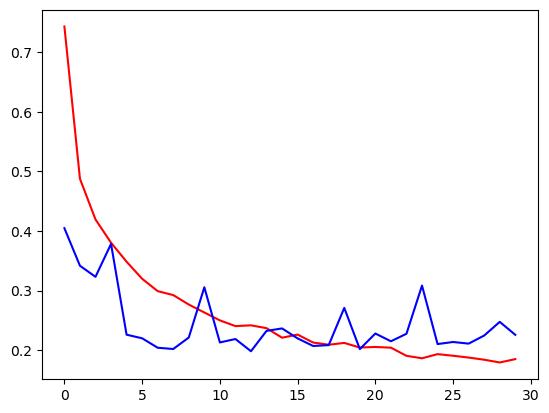

In [20]:
plt.plot(history.history['loss'], color='red', label='Train Data')
plt.plot(history.history['val_loss'], color='blue', label='Validation Data')

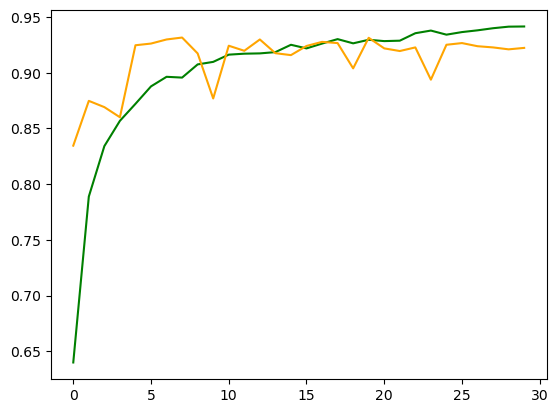

In [21]:
plt.plot(history.history['accuracy'], color='green', label='Train Data')
plt.plot(history.history['val_accuracy'], color='orange', label='Validation Data')

In [22]:
model.save('FinalData.h5', 'wb')

c:\Users\moomad\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
nl = data.columns.to_list()

In [ ]:
import seaborn as sns
for i in data.columns.to_list():
    print(f'Plot for {i} at below' )
    sns.histplot(data[i])
    plt.show()